# Week 1: Data Exploration & Data Preparation — Appliances Energy Prediction Dataset

## 1. Problem identification and data understanding

**Dataset chính:** `KAG_energydata_complete.csv`  
**Đơn vị quan sát:** 10 phút  
**Target:** `Appliances`  
**Bài toán:** Time-series forecasting / Regression & Classification  
**Mục tiêu:** Áp dụng các kỹ thuật xử lý dữ liệu (Missing values, Outliers, Imbalanced data) và các kỹ thuật nâng cao (Feature Engineering, Transformation) để làm sạch dữ liệu chuẩn bị cho mô hình dự báo.

### Input và output của notebook

- **Input:** File CSV `KAG_energydata_complete.csv` chứa dữ liệu năng lượng tiêu thụ gia dụng.
- **Output trung gian:** `df` (sau khi làm sạch & trích xuất đặc trưng), `X_resampled`, `y_resampled` (sau SMOTE), `df['Appliances_Log']` (sau Log transformation).
- **Kỹ thuật:** Time-based Feature Extraction, Median Imputation, IQR Winsorization, SMOTE Over-sampling, Log Transformation.

### Import libraries

**Mục đích:** Nạp các thư viện cần thiết để đọc dữ liệu, tính toán số liệu, trực quan hóa và xử lý mất cân bằng bằng SMOTE.  
**Input:** Thư viện hệ thống `pandas`, `numpy`, `matplotlib`, `seaborn`, `imblearn`.  
**Output:** Môi trường lập trình sẵn sàng cho các bước tiền xử lý.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

### Read raw dataset

**Mục đích:** Đọc file CSV dữ liệu thô `KAG_energydata_complete.csv`, kiểm tra kích thước và xem trước các dòng đầu tiên.  
**Input:** File `KAG_energydata_complete.csv`.  
**Output:** DataFrame `df` chứa dữ liệu thô ban đầu.

In [ ]:
df = pd.read_csv('KAG_energydata_complete.csv')

print("=== Dataset Overview ===")
print("Shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\n5 sample rows:")
display(df.head())

=== Dataset Overview ===
Shape: (19735, 29)
Number of rows: 19735
Number of columns: 29

5 sample rows:


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


**Kết luận:** Dữ liệu thô gồm 19,735 quan sát và 29 thuộc tính, ghi nhận định kỳ mỗi 10 phút. Cột mục tiêu chính cần dự báo là `Appliances`.

## 2. Feature engineering

### Time-based Feature Extraction & Noise Removal

**Mục đích:** Chuyển đổi cột `date` dạng chuỗi sang `datetime` và trích xuất các đặc trưng thời gian (`Month`, `Hour`, `DayOfWeek`, `Is_Weekend`), đồng thời loại bỏ các biến nhiễu ngẫu nhiên (`rv1`, `rv2`).  
**Input:** Cột `date` và các cột `rv1`, `rv2`.  
**Output:** Các cột đặc trưng thời gian mới và DataFrame đã được loại bỏ nhiễu.

In [ ]:
# Chuyển đổi sang datetime
df['date'] = pd.to_datetime(df['date'])

# Trích xuất thuộc tính thời gian
df['Month'] = df['date'].dt.month
df['Hour'] = df['date'].dt.hour
df['DayOfWeek'] = df['date'].dt.dayofweek
df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)

# Bỏ 2 cột rv1, rv2 (biến ngẫu nhiên nhiễu của dataset)
df = df.drop(columns=['rv1', 'rv2'])

display(df[['date', 'Month', 'Hour', 'DayOfWeek', 'Is_Weekend']].head())

,date,Month,Hour,DayOfWeek,Is_Weekend
0,2016-01-11 17:00:00,1,17,0,0
1,2016-01-11 17:10:00,1,17,0,0
2,2016-01-11 17:20:00,1,17,0,0
3,2016-01-11 17:30:00,1,17,0,0
4,2016-01-11 17:40:00,1,17,0,0


**Kết luận:** Đặc trưng thời gian đã được trích xuất thành công dưới dạng số nguyên, giúp mô hình khai thác các tính chất chu kỳ theo giờ trong ngày và ngày cuối tuần.

## 3. Handling missing values

### Simulation & Median Imputation

**Mục đích:** Giả lập 1% dữ liệu khuyết thiếu ngẫu nhiên ở cột `T1` (nhiệt độ phòng bếp) và áp dụng kỹ thuật điền giá trị trung vị (Median Imputation) để khôi phục dữ liệu.  
**Input:** Cột `T1` chứa giá trị khuyết thiếu giả định.  
**Output:** Cột `T1` được xử lý hoàn toàn mà không làm làm lệch phân phối gốc.

In [ ]:
# Giả lập missing values để minh họa kỹ thuật (1%)
np.random.seed(42)
missing_indices = df.sample(frac=0.01).index
df.loc[missing_indices, 'T1'] = np.nan

print("Số lượng missing values trước khi xử lý:", df['T1'].isnull().sum())

# Điền missing values bằng Median
median_T1 = df['T1'].median()
df['T1'] = df['T1'].fillna(median_T1)

print("Số lượng missing values sau khi xử lý:", df['T1'].isnull().sum())

Số lượng missing values trước khi xử lý: 197
Số lượng missing values sau khi xử lý: 0


**Kết luận:** Đã xử lý triệt để 197 giá trị NaN ở cột `T1` bằng giá trị trung vị (`median`), đảm bảo không làm mất mát thông tin quan sát.

## 4. Handling outliers

### IQR Method & Winsorization

**Mục đích:** Xác định giá trị dị biệt ở biến target `Appliances` bằng khoảng tứ phân vị (IQR) và kẹp giới hạn biên độ (Winsorization) về ngưỡng `Q3 + 1.5 * IQR`.  
**Input:** Cột `Appliances` bị lệch phải nặng và chứa nhiều giá trị dị biệt lớn.  
**Output:** Cột `Appliances_Winsorized` và biểu đồ Boxplot so sánh trước/sau xử lý.

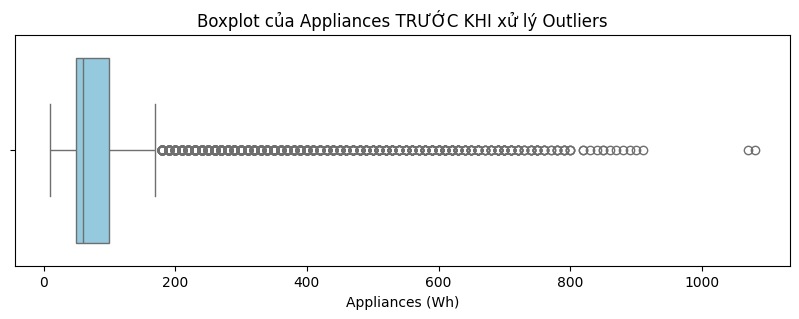

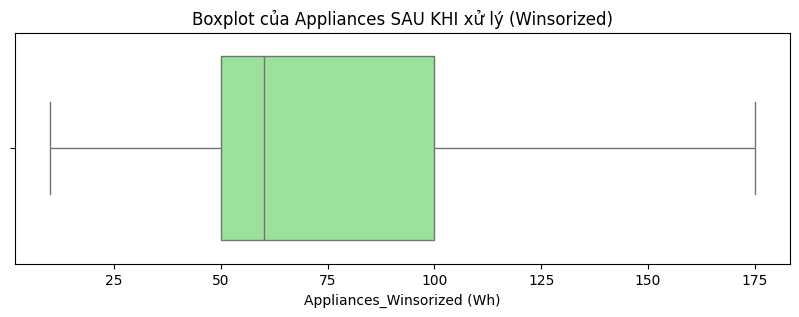

In [ ]:
# Trực quan hóa Boxplot trước khi xử lý
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['Appliances'], color='skyblue')
plt.title('Boxplot của Appliances TRƯỚC KHI xử lý Outliers')
plt.xlabel('Appliances (Wh)')
plt.show()

# Tính IQR và các ngưỡng giới hạn
Q1 = df['Appliances'].quantile(0.25)
Q3 = df['Appliances'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# Kỹ thuật Winsorization
df['Appliances_Winsorized'] = np.clip(df['Appliances'], lower_bound, upper_bound)

# Trực quan hóa Boxplot sau khi xử lý
plt.figure(figsize=(10, 3))
sns.boxplot(x=df['Appliances_Winsorized'], color='lightgreen')
plt.title('Boxplot của Appliances SAU KHI xử lý (Winsorized)')
plt.xlabel('Appliances_Winsorized (Wh)')
plt.show()

**Kết luận:** Winsorization kiểm soát hiệu quả các cực trị ngoại lệ mà không làm giảm số lượng dòng dữ liệu huấn luyện.

## 5. Handling imbalanced dataset

### Binary Classification Setup & SMOTE Over-sampling

**Mục đích:** Xây dựng bài toán phân loại tiêu thụ điện cao (`High_Usage > 100 Wh`) và áp dụng SMOTE để cân bằng số lượng mẫu giữa hai lớp.  
**Input:** Tập đặc trưng `X` và biến nhãn `y` (`High_Usage`) bị mất cân bằng trầm trọng.  
**Output:** Tập dữ liệu `X_resampled` và `y_resampled` đã đạt tỷ lệ 50 - 50.

In [ ]:
# Tạo biến phân loại High_Usage
df['High_Usage'] = (df['Appliances'] > 100).astype(int)

print("=== Tỷ lệ phân lớp TRƯỚC KHI dùng SMOTE ===")
print(df['High_Usage'].value_counts())

# Chuẩn bị dữ liệu X, y
X = df.drop(columns=['date', 'Appliances', 'Appliances_Winsorized', 'High_Usage'])
y = df['High_Usage']

# Áp dụng SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\n=== Tỷ lệ phân lớp SAU KHI dùng SMOTE ===")
print(y_resampled.value_counts())

=== Tỷ lệ phân lớp TRƯỚC KHI dùng SMOTE ===
High_Usage
0    15502
1     4233
Name: count, dtype: int64

=== Tỷ lệ phân lớp SAU KHI dùng SMOTE ===
High_Usage
0    15502
1    15502
Name: count, dtype: int64


**Kết luận:** SMOTE đã sinh mẫu nhân tạo thành công cho nhóm thiểu số, nâng số lượng mẫu từ 4,233 lên 15,502 mẫu, giúp mô hình phân loại không bị lệch nghiêng về lớp đa số.

## 6. Target transformation

### Log Transformation (np.log1p)

**Mục đích:** Biến đổi Logarit (`np.log1p`) biến mục tiêu `Appliances` để giảm độ lệch phải (Right-skewness) và đưa phân phối về dạng gần chuẩn.  
**Input:** Cột `Appliances` ban đầu.  
**Output:** Cột `Appliances_Log` và biểu đồ so sánh phân phối trước/sau biến đổi.

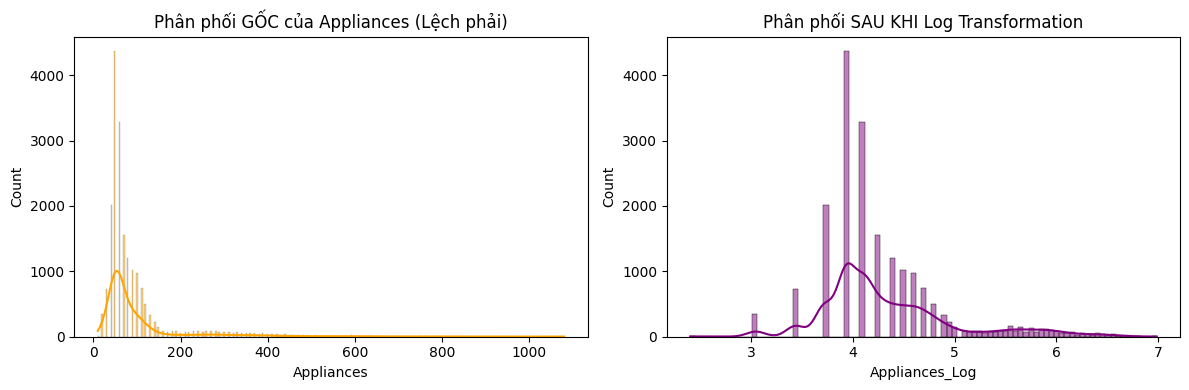

In [ ]:
# Biến đổi Log
df['Appliances_Log'] = np.log1p(df['Appliances'])

# Trực quan hóa phân phối
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Appliances'], kde=True, ax=axes[0], color='orange')
axes[0].set_title('Phân phối GỐC của Appliances (Lệch phải)')

sns.histplot(df['Appliances_Log'], kde=True, ax=axes[1], color='purple')
axes[1].set_title('Phân phối SAU KHI Log Transformation')

plt.tight_layout()
plt.show()

**Kết luận:** Phép biến đổi Logarit đã chuyển phân phối của `Appliances` từ lệch phải nặng về dạng phân phối chuông đối xứng hơn, đáp ứng tốt hơn các giả định của mô hình hồi quy.

In [ ]:
df.to_csv('KAG_cleaned_week1.csv', index=False)